## MOTIFS AND DISCORDS
### COMPARISON WITH SHAPELETS

In [ ]:
# !pip install matrixprofile-ts

  Obtaining dependency information for matrixprofile-ts from https://files.pythonhosted.org/packages/48/29/6d2067e8632b9a9b734501653a0f68d19c557add2b15427675b9fdc615b1/matrixprofile_ts-0.0.9-py2.py3-none-any.whl.metadata


In [ ]:
# !pip install stumpy

  Obtaining dependency information for stumpy from https://files.pythonhosted.org/packages/43/0f/305bc39f513eb7cb6406f1cd445f58f2b260526693afbe900dc6e9802410/stumpy-1.13.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/176.5 kB ? eta -:--:--
   ------ --------------------------------- 30.7/176.5 kB 1.4 MB/s eta 0:00:01
   ---------------------------------------- 176.5/176.5 kB 2.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matrixprofile import *

#### Load and visualize sample data

In [4]:
df = pd.read_csv('df_finale.csv')

In [5]:
df_timeseries = df.iloc[:, :100]

In [5]:
df_timeseries

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,3.203808,3.310528,3.080549,2.714583,2.409941,1.993775,1.583635,1.246871,0.796810,0.508554,...,-0.764454,-0.773251,-0.785931,-0.803325,-0.819292,-0.826546,-0.800523,-0.780994,-0.758548,-0.731235
1,1.641869,1.789420,1.837915,1.826346,1.841613,1.608536,1.322736,1.058922,0.766201,0.509104,...,0.138013,0.091804,-0.046413,-0.296589,-0.555315,-0.811598,-0.923964,-0.900554,-0.895424,-0.931546
2,2.146533,2.074483,1.922000,1.688202,1.367001,1.099541,0.879503,0.663925,0.466093,0.366285,...,-0.755742,-0.758995,-0.769806,-0.782269,-0.789811,-0.797837,-0.803927,-0.801292,-0.798581,-0.795879
3,1.244228,0.974971,0.792436,0.658828,0.110609,-0.230373,-0.290343,-0.352859,-0.421936,-0.490316,...,-0.147746,-0.366959,-0.498499,-0.525716,-0.548996,-0.568911,-0.587338,-0.602909,-0.612658,-0.613246
4,2.958126,2.791581,2.692438,2.631157,2.300224,2.052480,1.904554,1.740678,1.606702,1.489338,...,-0.649936,-0.646453,-0.645161,-0.645457,-0.647903,-0.651366,-0.656044,-0.661063,-0.665579,-0.668798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1129,3.930861,3.678304,3.339795,2.963937,2.483528,2.027932,1.564115,1.153334,0.836055,0.641848,...,-0.581129,-0.582350,-0.584734,-0.588441,-0.591204,-0.592680,-0.593513,-0.593650,-0.593869,-0.594236
1130,2.917085,2.810270,2.618698,2.314326,2.073896,2.056742,1.890531,1.667496,1.459727,1.321335,...,-0.681302,-0.688884,-0.696743,-0.702418,-0.706121,-0.709908,-0.710889,-0.710866,-0.709265,-0.704758
1131,3.558092,3.264517,2.947922,2.588963,2.087472,1.656590,1.244943,0.928361,0.700896,0.570797,...,-0.521695,-0.547282,-0.579174,-0.602577,-0.644120,-0.707286,-0.765331,-0.802150,-0.828583,-0.841612
1132,3.468692,3.669017,3.510363,3.077339,2.725131,2.253547,1.699255,1.092181,0.427260,0.010953,...,-0.468632,-0.486256,-0.508885,-0.540992,-0.570104,-0.590912,-0.601979,-0.604438,-0.608394,-0.614915


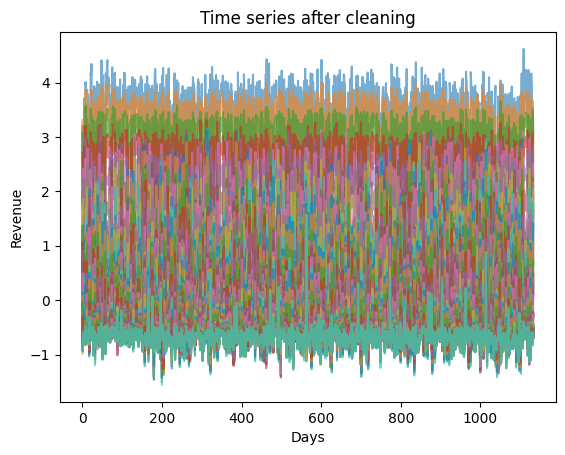

In [6]:
df_timeseries.plot(legend = False, alpha = 0.6)
plt.title('Time series after cleaning')
plt.xlabel('Days')
plt.ylabel('Revenue')
plt.show()

### Calculating the matrix profile

matrixProfile.stomp: stomp prende una sola serie come input, quindi bisogna iterare su ogni time serie. 

In [7]:
m = 7
all_cac = []

In [8]:
# questo per tutte le time series

# for i,ts in enumerate(df_timeseries.T.values):
#     profile = matrixProfile.stomp(ts, m)

#     mp_values, mpi = profile['mp'], profile['pi']

#     cac = fluss.fluss(mpi,m)
#     all_cac.append(cac)

#     fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
#     axs[0].plot(ts)
#     axs[0].set_title(f"Serie {i+1}")
    
#     axs[1].plot(mp_values)
#     axs[1].set_title("Matrix Profile")
    
#     axs[2].plot(cac)
#     axs[2].set_title("Corrected Arc Curve (CAC)")
#     plt.tight_layout()
#     plt.show()


In [9]:
df_timeseries

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,3.203808,3.310528,3.080549,2.714583,2.409941,1.993775,1.583635,1.246871,0.796810,0.508554,...,-0.764454,-0.773251,-0.785931,-0.803325,-0.819292,-0.826546,-0.800523,-0.780994,-0.758548,-0.731235
1,1.641869,1.789420,1.837915,1.826346,1.841613,1.608536,1.322736,1.058922,0.766201,0.509104,...,0.138013,0.091804,-0.046413,-0.296589,-0.555315,-0.811598,-0.923964,-0.900554,-0.895424,-0.931546
2,2.146533,2.074483,1.922000,1.688202,1.367001,1.099541,0.879503,0.663925,0.466093,0.366285,...,-0.755742,-0.758995,-0.769806,-0.782269,-0.789811,-0.797837,-0.803927,-0.801292,-0.798581,-0.795879
3,1.244228,0.974971,0.792436,0.658828,0.110609,-0.230373,-0.290343,-0.352859,-0.421936,-0.490316,...,-0.147746,-0.366959,-0.498499,-0.525716,-0.548996,-0.568911,-0.587338,-0.602909,-0.612658,-0.613246
4,2.958126,2.791581,2.692438,2.631157,2.300224,2.052480,1.904554,1.740678,1.606702,1.489338,...,-0.649936,-0.646453,-0.645161,-0.645457,-0.647903,-0.651366,-0.656044,-0.661063,-0.665579,-0.668798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1129,3.930861,3.678304,3.339795,2.963937,2.483528,2.027932,1.564115,1.153334,0.836055,0.641848,...,-0.581129,-0.582350,-0.584734,-0.588441,-0.591204,-0.592680,-0.593513,-0.593650,-0.593869,-0.594236
1130,2.917085,2.810270,2.618698,2.314326,2.073896,2.056742,1.890531,1.667496,1.459727,1.321335,...,-0.681302,-0.688884,-0.696743,-0.702418,-0.706121,-0.709908,-0.710889,-0.710866,-0.709265,-0.704758
1131,3.558092,3.264517,2.947922,2.588963,2.087472,1.656590,1.244943,0.928361,0.700896,0.570797,...,-0.521695,-0.547282,-0.579174,-0.602577,-0.644120,-0.707286,-0.765331,-0.802150,-0.828583,-0.841612
1132,3.468692,3.669017,3.510363,3.077339,2.725131,2.253547,1.699255,1.092181,0.427260,0.010953,...,-0.468632,-0.486256,-0.508885,-0.540992,-0.570104,-0.590912,-0.601979,-0.604438,-0.608394,-0.614915


In [10]:
df_timeseries = df_timeseries.T

In [11]:
profile = matrixProfile.stomp((df_timeseries[0].to_numpy()), m)
mp, mpi = profile[0], profile[1]

cac = fluss.fluss(mpi,m)

/Users/laviniarotellini/Desktop/DM2/.venv/lib/python3.13/site-packages/matrixprofile/fluss.py:58: RuntimeWarning: invalid value encountered in divide
  idealized = cross_count / idealized


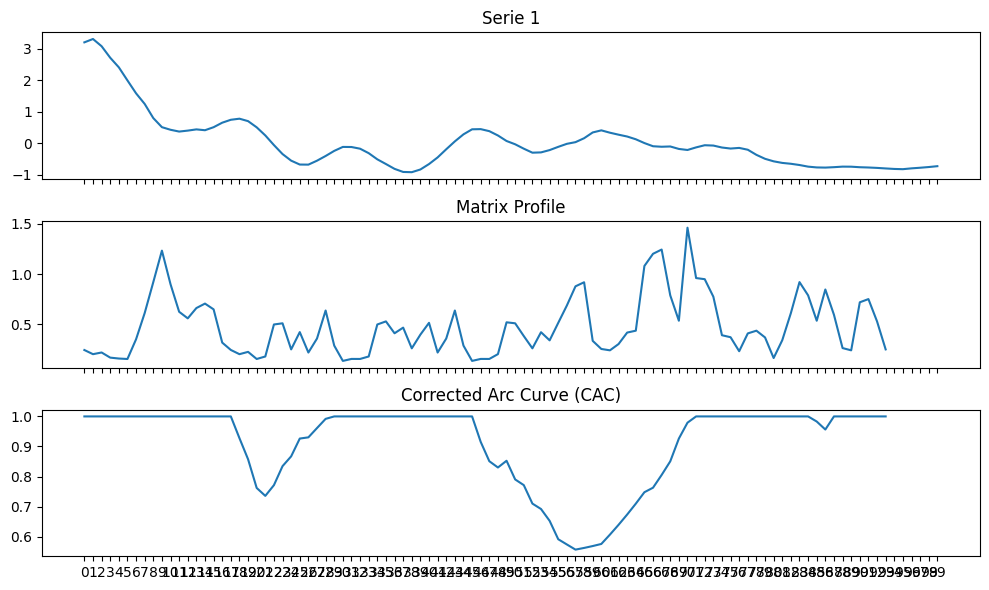

In [12]:
fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
axs[0].plot(df_timeseries[0])
axs[0].set_title("Serie 1")
    
axs[1].plot(mp)
axs[1].set_title("Matrix Profile")
    
axs[2].plot(cac)
axs[2].set_title("Corrected Arc Curve (CAC)")
plt.tight_layout()
plt.show()

### Trovare i motifs

In [13]:
mtfs, motif_d = motifs.motifs(df_timeseries[0], profile, max_motifs=10)

In [14]:
def plot_motifs(mtfs, labels, ax, pattern):

    colori = 0
    colors = 'rgbcm'
    for ms,l in zip(mtfs,labels):
        c =colors[colori % len(colors)]
        starts = list(ms)
        ends = [min(s + m,len(pattern)-1) for s in starts]
        ax.plot(starts, pattern[starts],  c +'o',  label=l)
        ax.plot(ends, pattern[ends],  c +'o', markerfacecolor='none')
        for nn in ms:
            ax.plot(range(nn,nn+m),pattern[nn:nn+m], c , linewidth=2)
        colori += 1

    ax.plot(pattern, 'k', linewidth=1, label="data")
    ax.legend()

/var/folders/32/wr6jfczj32q0c3fcn7fkrtvr0000gn/T/ipykernel_1121/1622678364.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.plot(starts, pattern[starts],  c +'o',  label=l)
/var/folders/32/wr6jfczj32q0c3fcn7fkrtvr0000gn/T/ipykernel_1121/1622678364.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.plot(ends, pattern[ends],  c +'o', markerfacecolor='none')


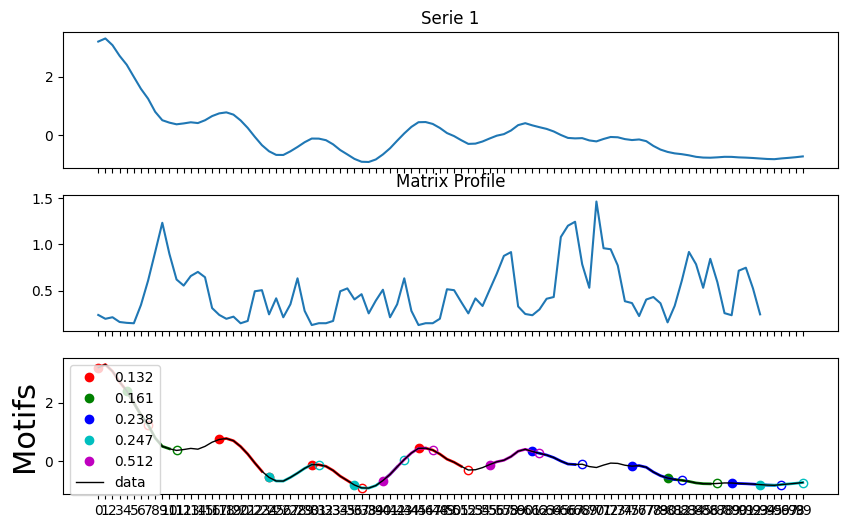

In [15]:
fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
axs[0].plot(df_timeseries[0])
axs[0].set_title("Serie 1")
    
axs[1].plot(mp)
axs[1].set_title("Matrix Profile")

#Plot the Motifs
plot_motifs(mtfs, [f"{md:.3f}" for md in motif_d], axs[2], df_timeseries[0])
axs[2].set_ylabel('Motifs', size=22)
#plt.xlim((0,100))
plt.show()

/var/folders/32/wr6jfczj32q0c3fcn7fkrtvr0000gn/T/ipykernel_1121/1622678364.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.plot(starts, pattern[starts],  c +'o',  label=l)
/var/folders/32/wr6jfczj32q0c3fcn7fkrtvr0000gn/T/ipykernel_1121/1622678364.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.plot(ends, pattern[ends],  c +'o', markerfacecolor='none')
/var/folders/32/wr6jfczj32q0c3fcn7fkrtvr0000gn/T/ipykernel_1121/1622678364.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame beha

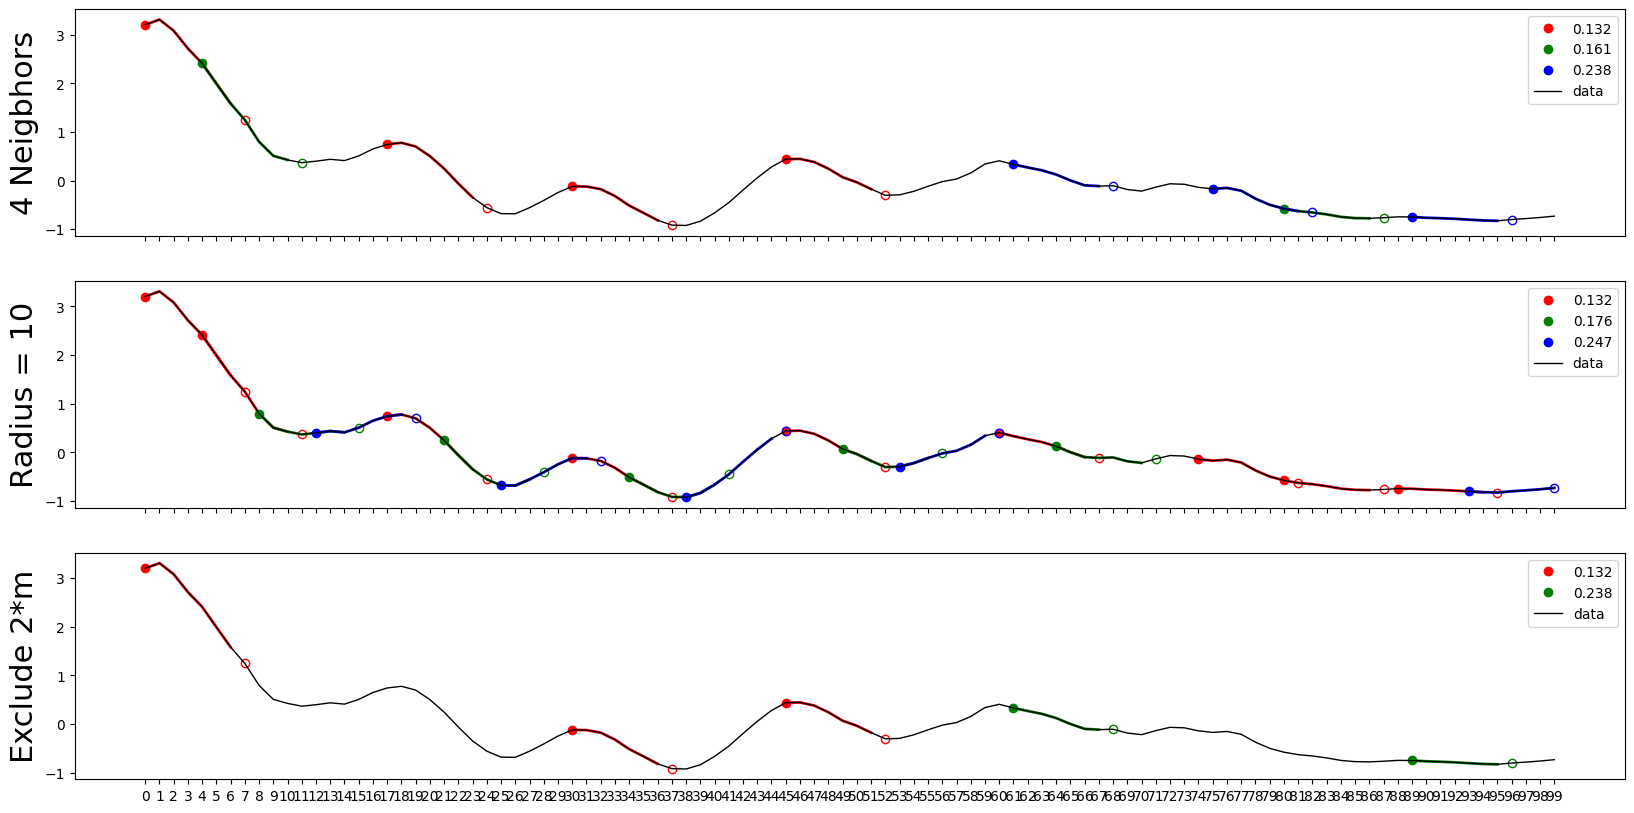

In [16]:
fig, (ax1, ax2, ax3) = plt.subplots(3,1,sharex=True,figsize=(20,10))


mtfs ,motif_d  = motifs.motifs(df_timeseries[0], profile, max_motifs=5, n_neighbors=4)
plot_motifs(mtfs, [f"{md:.3f}" for md in motif_d], ax1, df_timeseries[0])
ax1.set_ylabel('4 Neigbhors', size=22)

mtfs ,motif_d  = motifs.motifs(df_timeseries[0], profile, max_motifs=5, radius=10)
plot_motifs(mtfs, [f"{md:.3f}" for md in motif_d], ax2, df_timeseries[0])
ax2.set_ylabel('Radius = 10', size=22)

mtfs ,motif_d  = motifs.motifs(df_timeseries[0], profile, max_motifs=5, ex_zone=2*m)
plot_motifs(mtfs, [f"{md:.3f}" for md in motif_d], ax3, df_timeseries[0])
ax3.set_ylabel('Exclude 2*m', size=22)
plt.show()

### Motifs e discords per tutti i film

In [ ]:
#! pip install tslearn

In [18]:
from matrixprofile.discords import discords
import tslearn.metrics

/Users/laviniarotellini/Desktop/DM2/.venv/lib/python3.13/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


In [19]:
df_timeseries = df_timeseries.T

In [20]:
all_motifs = {}
all_discords = {}

for film in df_timeseries.index:
    ts = df_timeseries.loc[film].values
    profile = matrixProfile.stomp(ts, m)
    mtfs, motif_d = motifs.motifs(ts, profile, max_motifs=5)
    anomalies = discords(profile[0], ex_zone=3, k=5)
    all_motifs[film] = {"motifs": mtfs, "distances": motif_d}
    all_discords[film] = {'discords': anomalies}


## Trovare i motifs comuni

In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import *

In [22]:
tot_motifs = []
motifs_sources = []

for film, res in all_motifs.items():
    for motifs in res['motifs']:
        for motif in motifs:
            tot_motifs.append(motif)
            motifs_sources.append(film)

In [23]:
# Checking different scores for different amount of clusters to find
def kmeans_optimization(data, max_k):
    data = np.array(data).reshape(-1, 1)

    ks = []
    inertias = []
    sil_scores = []

    for k in range(2, max_k+1):
        kmeans = KMeans(init='k-means++', n_clusters=k, n_init=10, max_iter=16000)
        cluster_labels  = kmeans.fit_predict(data)

        ks.append(k)
        inertias.append(kmeans.inertia_)
    
        # più la silhouette è vicina ad 1, migliore è il clustering
        sil_scores.append(silhouette_score(data, cluster_labels))

    # Genero il plot per inertia
    fig = plt.subplots(figsize = (10,5))
    plt.plot(ks, inertias, 'o-')
    plt.xlabel('Number of clusters')
    plt.ylabel('Inertia (SSE)')
    plt.grid(True)
    plt.show()

    # Genero il plot per la silhouette
    fig = plt.subplots(figsize = (10,5))
    plt.plot(ks, sil_scores, 'o-', color = 'orange')
    plt.xlabel('Number of clusters')
    plt.ylabel('Silhouette Scores')
    plt.grid(True)
    plt.show()

/Users/laviniarotellini/Desktop/DM2/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/laviniarotellini/Desktop/DM2/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/laviniarotellini/Desktop/DM2/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/laviniarotellini/Desktop/DM2/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/laviniarotellini/Desktop/DM2/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_

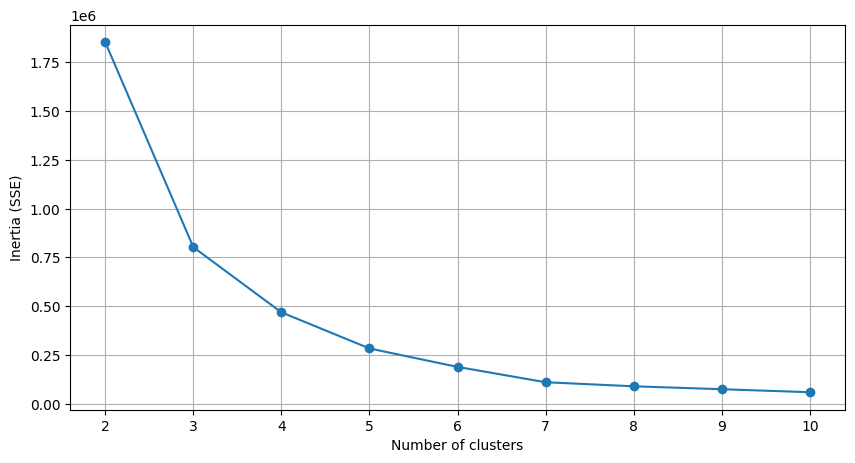

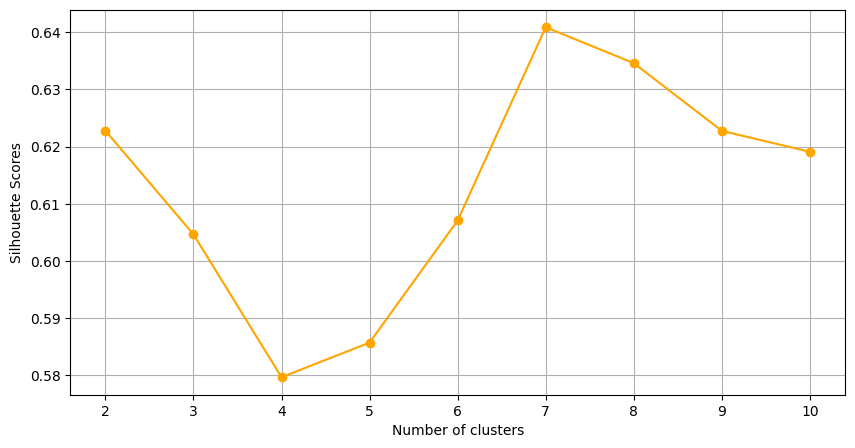

In [24]:
kmeans_optimization(tot_motifs, 10)

In [25]:
kmeans = KMeans(init='k-means++', n_clusters=7)
clusters = kmeans.fit_predict(np.array(tot_motifs).reshape(-1, 1))

/Users/laviniarotellini/Desktop/DM2/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/laviniarotellini/Desktop/DM2/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/laviniarotellini/Desktop/DM2/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight


In [26]:
print('labels', np.unique(kmeans.labels_, return_counts=True))
print('inertia', kmeans.inertia_)
print('silhouette', silhouette_score(np.array(tot_motifs).reshape(-1, 1), kmeans.labels_))

labels (array([0, 1, 2, 3, 4, 5, 6], dtype=int32), array([1273, 1569, 1202, 1492, 1062, 1436, 1561]))
inertia 112082.57137193954
silhouette 0.6416552017555878


Cluster che contengono pattern comuni a tutti i film

In [27]:
from collections import defaultdict

In [28]:
common_motifs = []

for cluster_id in set(clusters):
    cluster_films = set()
    cluster_patterns = []

    cluster_counts = defaultdict(int)
    cluster_members = defaultdict(list)
        
    for i, c in enumerate(clusters):
        cluster_counts[c] +=1
        cluster_members[c].append((i, motifs_sources[i]))

    sorted_clusters = sorted(cluster_counts.items(), key=lambda x: x[1], reverse=True)

In [29]:
from scipy.stats import pearsonr

In [30]:
def find_common_motifs_debug(all_motifs, correlation_threshold=0.7):
    """
    Versione semplice per debug - stampa cosa sta facendo
    """
    films = list(all_motifs.keys())
    print(f"Analizzando {len(films)} film")
    
    for film in films:
        print(f"{film}: {len(all_motifs[film])} motifs")
    
    common_motifs = []
    
    for ref_film in films:
        print(f"\n--- Analizzando film di riferimento: {ref_film} ---")
        
        for i, ref_motif in enumerate(all_motifs[ref_film]):
            print(f"  Motif {i} (lunghezza {len(ref_motif)})")
            
            matches = {ref_film: ref_motif}
            
            for target_film in films:
                if target_film != ref_film:
                    best_corr = 0
                    best_motif = None
                    
                    for target_motif in all_motifs[target_film]:
                        if len(ref_motif) == len(target_motif):
                            corr, _ = pearsonr(ref_motif, target_motif)
                            if abs(corr) > best_corr:
                                best_corr = abs(corr)
                                best_motif = target_motif
                    
                    print(f"    vs {target_film}: migliore correlazione = {best_corr:.3f}")
                    
                    if best_corr > correlation_threshold:
                        matches[target_film] = best_motif
            
            coverage = len(matches) / len(films)
            print(f"    Copertura: {len(matches)}/{len(films)} = {coverage:.2%}")
            
            if len(matches) == len(films):  # Trovato in tutti i film
                common_motifs.append({
                    'reference_film': ref_film,
                    'reference_motif_index': i,
                    'patterns': matches,
                    'coverage': coverage
                })
                print(f"    ✓ MOTIF COMUNE TROVATO!")
    
    print(f"\nTotale motifs comuni trovati: {len(common_motifs)}")
    return common_motifs

In [31]:
# Prova la versione debug prima
common_motifs = find_common_motifs_debug(all_motifs, correlation_threshold=0.6)

# Se non trova nulla, abbassa la soglia o cambia metrica
if not common_motifs:
    print("Nessun motif comune trovato. Provo con soglia più bassa...")
    common_motifs = find_common_motifs_debug(all_motifs, correlation_threshold=0.4)

Analizzando 1134 film
0: 2 motifs
1: 2 motifs
2: 2 motifs
3: 2 motifs
4: 2 motifs
5: 2 motifs
6: 2 motifs
7: 2 motifs
8: 2 motifs
9: 2 motifs
10: 2 motifs
11: 2 motifs
12: 2 motifs
13: 2 motifs
14: 2 motifs
15: 2 motifs
16: 2 motifs
17: 2 motifs
18: 2 motifs
19: 2 motifs
20: 2 motifs
21: 2 motifs
22: 2 motifs
23: 2 motifs
24: 2 motifs
25: 2 motifs
26: 2 motifs
27: 2 motifs
28: 2 motifs
29: 2 motifs
30: 2 motifs
31: 2 motifs
32: 2 motifs
33: 2 motifs
34: 2 motifs
35: 2 motifs
36: 2 motifs
37: 2 motifs
38: 2 motifs
39: 2 motifs
40: 2 motifs
41: 2 motifs
42: 2 motifs
43: 2 motifs
44: 2 motifs
45: 2 motifs
46: 2 motifs
47: 2 motifs
48: 2 motifs
49: 2 motifs
50: 2 motifs
51: 2 motifs
52: 2 motifs
53: 2 motifs
54: 2 motifs
55: 2 motifs
56: 2 motifs
57: 2 motifs
58: 2 motifs
59: 2 motifs
60: 2 motifs
61: 2 motifs
62: 2 motifs
63: 2 motifs
64: 2 motifs
65: 2 motifs
66: 2 motifs
67: 2 motifs
68: 2 motifs
69: 2 motifs
70: 2 motifs
71: 2 motifs
72: 2 motifs
73: 2 motifs
74: 2 motifs
75: 2 motifs


IndexError: tuple index out of range

## Codice CLAUDE

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import euclidean
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Configurazione matplotlib
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

In [6]:
data = df_timeseries.values

In [7]:
motif_length = 7          # Lunghezza pattern da cercare
top_k_per_serie = 5        # Motifs migliori per serie
n_clusters = 5              # Numero cluster
distance_threshold = 0.8    # Soglia similarità cross-series

In [8]:
print(f"\n📋 Statistiche base:")
print(f"Min: {np.min(data):.3f}")
print(f"Max: {np.max(data):.3f}")
print(f"Media: {np.mean(data):.3f}")
print(f"Std: {np.std(data):.3f}")


📋 Statistiche base:
Min: -1.559
Max: 4.620
Media: 0.006
Std: 0.894


In [9]:
# Cell 3: Definizione della Classe TimeSeriesMotifAnalyzer
class TimeSeriesMotifAnalyzer:
    def __init__(self, data, motif_length=10):
        """
        Inizializza l'analizzatore di motifs per time series multiple
        """
        self.data = np.array(data)
        self.n_series, self.n_timestamps = self.data.shape
        self.motif_length = motif_length
        self.motifs = {}
        self.motif_matrix = None
        self.distance_matrix = None
        
        print(f"🔧 Analizzatore inizializzato:")
        print(f"   📊 {self.n_series} serie temporali")
        print(f"   ⏱️  {self.n_timestamps} timestamp")
        print(f"   📏 Lunghezza motif: {self.motif_length}")
    
    def extract_subsequences(self, series_idx):
        """Estrae tutte le subsequenze possibili da una serie temporale"""
        series = self.data[series_idx]
        subsequences = []
        
        for i in range(len(series) - self.motif_length + 1):
            subseq = series[i:i + self.motif_length]
            subsequences.append({
                'series_idx': series_idx,
                'start_pos': i,
                'end_pos': i + self.motif_length - 1,
                'raw_data': subseq,
                'normalized_data': subseq
            })
        
        return subsequences
    
    def find_motifs_single_series(self, series_idx, top_k=5):
        """Trova i migliori motifs all'interno di una singola serie"""
        subsequences = self.extract_subsequences(series_idx)
        n_subseq = len(subsequences)
        
        # Matrice delle distanze
        distances = np.full((n_subseq, n_subseq), np.inf)
        
        for i in range(n_subseq):
            for j in range(i + 1, n_subseq):
                # Evita sovrapposizioni troppo vicine
                if abs(i - j) >= self.motif_length:
                    dist = euclidean(subsequences[i]['normalized_data'], 
                                   subsequences[j]['normalized_data'])
                    distances[i, j] = dist
                    distances[j, i] = dist
        
        # Trova le coppie di motifs migliori
        motif_pairs = []
        for i in range(n_subseq):
            min_dist_idx = np.argmin(distances[i])
            min_dist = distances[i, min_dist_idx]
            
            if min_dist != np.inf:
                motif_pairs.append({
                    'series_idx': series_idx,
                    'subseq1': subsequences[i],
                    'subseq2': subsequences[min_dist_idx],
                    'distance': min_dist,
                    'pair_idx': (i, min_dist_idx)
                })
        
        # Ordina per distanza e rimuovi duplicati
        motif_pairs.sort(key=lambda x: x['distance'])
        unique_motifs = []
        used_indices = set()
        
        for motif in motif_pairs:
            i, j = motif['pair_idx']
            if i not in used_indices and j not in used_indices:
                unique_motifs.append(motif)
                used_indices.add(i)
                used_indices.add(j)
                if len(unique_motifs) >= top_k:
                    break
        
        return unique_motifs
    
    def find_all_motifs(self, top_k_per_series=3):
        """Trova motifs per tutte le serie temporali"""
        print("🔍 Estrazione motifs da tutte le serie temporali...")
        
        for series_idx in range(self.n_series):
            if series_idx % 100 == 0:
                print(f"   📊 Processando serie {series_idx}/{self.n_series}")
            
            motifs = self.find_motifs_single_series(series_idx, top_k_per_series)
            self.motifs[series_idx] = motifs
        
        total_motifs = sum(len(motifs) for motifs in self.motifs.values())
        print(f"✅ Motifs estratti: {total_motifs} totali da {len(self.motifs)} serie")
    
    def create_motif_feature_matrix(self):
        """Crea una matrice delle caratteristiche dei motifs per il confronto tra serie"""
        print("🛠️  Creazione matrice delle caratteristiche dei motifs...")
        
        features_list = []
        series_indices = []
        
        for series_idx, motifs in self.motifs.items():
            if motifs:  # Se ci sono motifs per questa serie
                # Caratteristiche aggregate dei motifs per serie
                distances = [m['distance'] for m in motifs]
                
                # Statistiche sui motifs
                features = [
                    np.mean(distances),           # Distanza media dei motifs
                    np.min(distances),            # Migliore motif (distanza minima)
                    np.std(distances),            # Variabilità delle distanze
                    len(motifs),                  # Numero di motifs trovati
                ]
                
                # Caratteristiche delle forme dei motifs migliori
                best_motif = motifs[0]  # Il migliore (distanza minima)
                motif_shape = best_motif['subseq1']['normalized_data']
                
                features.extend([
                    np.mean(motif_shape),         # Media della forma
                    np.std(motif_shape),          # Variabilità della forma
                    np.max(motif_shape),          # Picco massimo
                    np.min(motif_shape),          # Valore minimo
                    np.ptp(motif_shape),          # Range (peak-to-peak)
                ])
                
                # Caratteristiche di trend
                features.extend([
                    motif_shape[-1] - motif_shape[0],  # Trend generale
                    np.sum(np.diff(motif_shape) > 0),  # Numero di aumenti
                    np.sum(np.diff(motif_shape) < 0),  # Numero di diminuzioni
                ])
                
                features_list.append(features)
                series_indices.append(series_idx)
        
        self.motif_matrix = np.array(features_list)
        self.series_indices = series_indices
        
        feature_names = [
            'mean_distance', 'min_distance', 'std_distance', 'n_motifs',
            'shape_mean', 'shape_std', 'shape_max', 'shape_min', 'shape_range',
            'trend', 'n_increases', 'n_decreases'
        ]
        
        self.motif_df = pd.DataFrame(self.motif_matrix, 
                                   index=series_indices, 
                                   columns=feature_names)
        
        print(f"✅ Matrice caratteristiche creata: {self.motif_matrix.shape}")
        return self.motif_df
    
    def cluster_series_by_motifs(self, n_clusters=5, method='kmeans'):
        """Raggruppa le serie temporali basandosi sui loro motifs"""
        if self.motif_matrix is None:
            self.create_motif_feature_matrix()
        
        scaled_features = self.motif_matrix
        
        if method == 'kmeans':
            # K-means clustering
            kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
            cluster_labels = kmeans.fit_predict(scaled_features)
            
            # Calcola silhouette score
            sil_score = silhouette_score(scaled_features, cluster_labels)
            print(f"🎯 K-means clustering completato. Silhouette score: {sil_score:.3f}")
            
        elif method == 'hierarchical':
            # Clustering gerarchico
            linkage_matrix = linkage(scaled_features, method='ward')
            cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust') - 1
            print(f"🎯 Clustering gerarchico completato")
        
        # Aggiungi i cluster al DataFrame
        self.motif_df['cluster'] = cluster_labels
        
        return cluster_labels, self.motif_df
    
    def find_similar_motifs_across_series(self, distance_threshold=1.0, top_k=10):
        """Trova motifs simili tra diverse serie temporali"""
        print("🔍 Ricerca motifs simili tra serie diverse...")
        
        all_motifs = []
        for series_idx, motifs in self.motifs.items():
            for motif in motifs:
                all_motifs.append({
                    'series_idx': series_idx,
                    'motif_data': motif['subseq1']['normalized_data'],
                    'motif_info': motif
                })
        
        # Confronta tutti i motifs tra loro
        cross_series_motifs = []
        
        for i in range(len(all_motifs)):
            for j in range(i + 1, len(all_motifs)):
                if all_motifs[i]['series_idx'] != all_motifs[j]['series_idx']:
                    dist = euclidean(all_motifs[i]['motif_data'], 
                                   all_motifs[j]['motif_data'])
                    
                    if dist < distance_threshold:
                        cross_series_motifs.append({
                            'series1': all_motifs[i]['series_idx'],
                            'series2': all_motifs[j]['series_idx'],
                            'distance': dist,
                            'motif1': all_motifs[i]['motif_info'],
                            'motif2': all_motifs[j]['motif_info']
                        })
        
        # Ordina per distanza
        cross_series_motifs.sort(key=lambda x: x['distance'])
        
        print(f"✅ Trovati {len(cross_series_motifs)} motifs simili tra serie diverse")
        
        return cross_series_motifs[:top_k]

In [10]:
# Inizializza l'analizzatore
analyzer = TimeSeriesMotifAnalyzer(data, motif_length=motif_length)

🔧 Analizzatore inizializzato:
   📊 1134 serie temporali
   ⏱️  100 timestamp
   📏 Lunghezza motif: 7


🔍 Estrazione motifs da tutte le serie temporali...
   📊 Processando serie 0/1134
   📊 Processando serie 100/1134
   📊 Processando serie 200/1134
   📊 Processando serie 300/1134
   📊 Processando serie 400/1134
   📊 Processando serie 500/1134
   📊 Processando serie 600/1134
   📊 Processando serie 700/1134
   📊 Processando serie 800/1134
   📊 Processando serie 900/1134
   📊 Processando serie 1000/1134
   📊 Processando serie 1100/1134
✅ Motifs estratti: 5670 totali da 1134 serie
🛠️  Creazione matrice delle caratteristiche dei motifs...
✅ Matrice caratteristiche creata: (1134, 12)
📋 Prime 10 righe della matrice delle caratteristiche:
   mean_distance  min_distance  std_distance  n_motifs  shape_mean  shape_std  \
0       0.149530      0.109789      0.024007       5.0   -0.759090   0.011743   
1       0.173270      0.134636      0.021664       5.0   -0.353819   0.051334   
2       0.022591      0.016157      0.005330       5.0   -0.755424   0.018139   
3       0.047022      0.019182      0.0

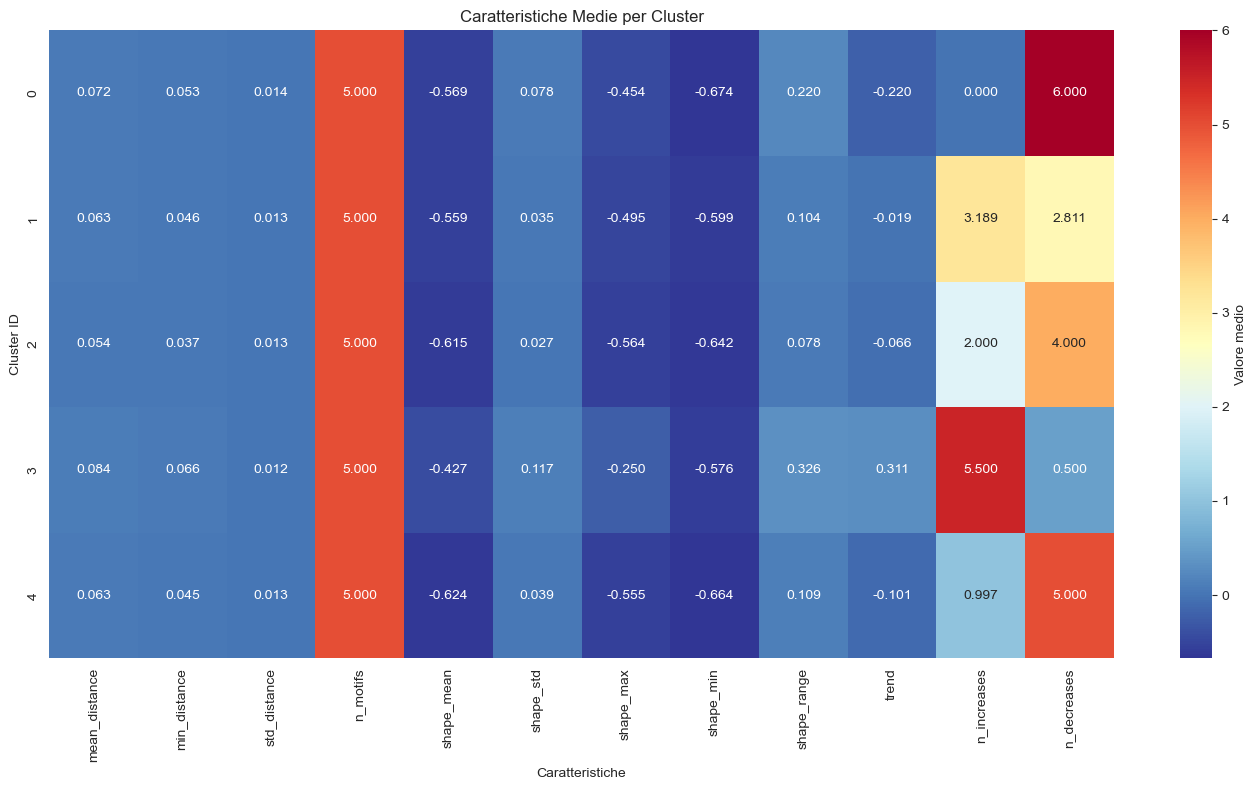

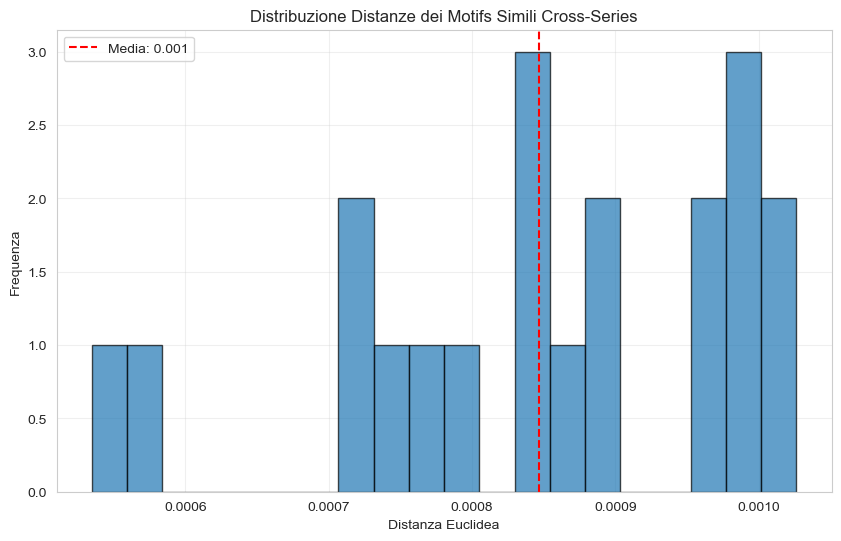

🎨 Visualizzazione serie rappresentative per cluster:


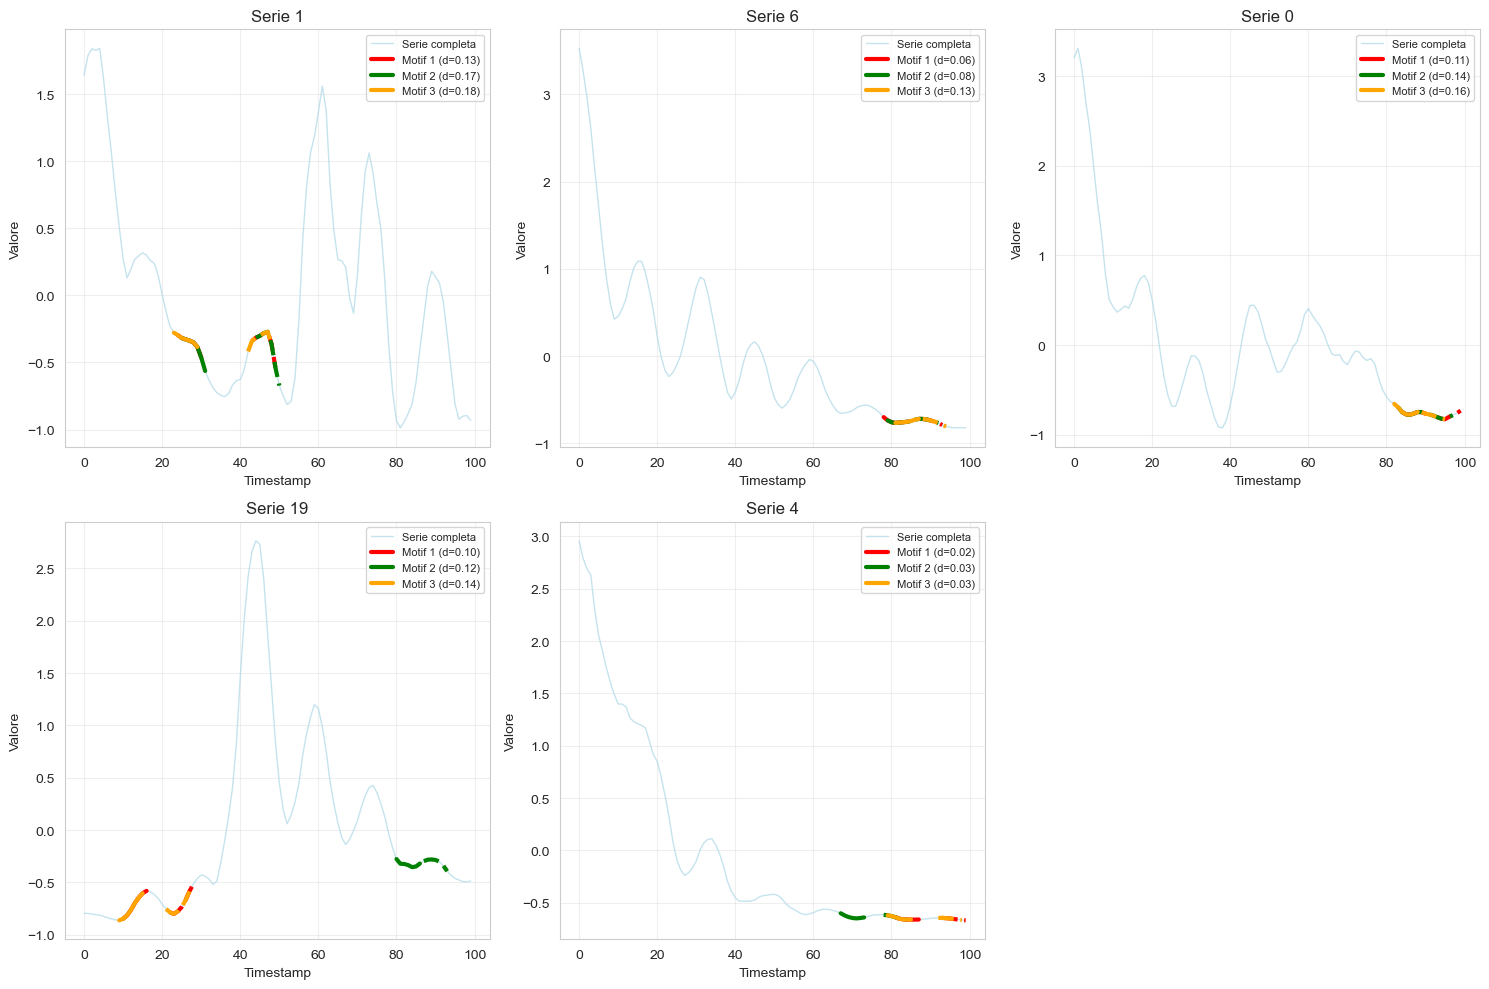

💾 Salvando risultati...
✅ Salvato: motif_features_and_clusters.csv
✅ Salvato: similar_motifs_cross_series.csv
✅ Salvato: motif_analysis_report.txt

🎉 ANALISI COMPLETATA!
📊 File generati:
   • motif_features_and_clusters.csv
   • similar_motifs_cross_series.csv
   • motif_analysis_report.txt


In [11]:
analyzer.find_all_motifs(top_k_per_series=top_k_per_serie)

# Cell 6: Creazione Matrice delle Caratteristiche
# Crea la matrice delle caratteristiche per confrontare le serie
motif_features = analyzer.create_motif_feature_matrix()

# Visualizza le prime righe
print("📋 Prime 10 righe della matrice delle caratteristiche:")
print(motif_features.head(10))

print(f"\n📊 Statistiche descrittive:")
print(motif_features.describe())

# Cell 7: Clustering delle Serie Temporali
# Esegui clustering basato sui motifs
N_CLUSTERS = 5  # Modifica questo valore
cluster_labels, clustered_df = analyzer.cluster_series_by_motifs(n_clusters=N_CLUSTERS)

# Visualizza distribuzione cluster
print(f"\n📊 Distribuzione delle serie per cluster:")
cluster_counts = clustered_df['cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    print(f"   Cluster {cluster_id}: {count} serie ({count/len(clustered_df)*100:.1f}%)")

# Cell 8: Analisi Caratteristiche per Cluster
print("🔍 ANALISI CARATTERISTICHE DEI CLUSTER")
print("="*50)

for cluster_id in sorted(clustered_df['cluster'].unique()):
    cluster_data = clustered_df[clustered_df['cluster'] == cluster_id]
    n_series = len(cluster_data)
    
    print(f"\n🎯 CLUSTER {cluster_id} ({n_series} serie)")
    print("-" * 30)
    
    # Caratteristiche principali
    print(f"Distanza media motifs: {cluster_data['mean_distance'].mean():.4f} ± {cluster_data['mean_distance'].std():.4f}")
    print(f"Qualità motifs (min_dist): {cluster_data['min_distance'].mean():.4f} ± {cluster_data['min_distance'].std():.4f}")
    print(f"Numero medio motifs: {cluster_data['n_motifs'].mean():.1f} ± {cluster_data['n_motifs'].std():.1f}")
    print(f"Trend medio: {cluster_data['trend'].mean():.4f} ± {cluster_data['trend'].std():.4f}")
    print(f"Range forme: {cluster_data['shape_range'].mean():.4f} ± {cluster_data['shape_range'].std():.4f}")
    
    # Serie più rappresentativa
    cluster_center = cluster_data.select_dtypes(include=[np.number]).drop('cluster', axis=1).mean()
    distances_to_center = np.linalg.norm(
        cluster_data.select_dtypes(include=[np.number]).drop('cluster', axis=1) - cluster_center, axis=1
    )
    representative_series = cluster_data.index[np.argmin(distances_to_center)]
    print(f"Serie più rappresentativa: {representative_series}")

# Cell 9: Ricerca Motifs Simili tra Serie Diverse
# Questo è il cuore dell'analisi cross-series!
DISTANCE_THRESHOLD = 0.8  # Modifica per cambiare la soglia di similarità
TOP_K_SIMILAR = 20

similar_motifs = analyzer.find_similar_motifs_across_series(
    distance_threshold=DISTANCE_THRESHOLD, 
    top_k=TOP_K_SIMILAR
)

print(f"🔍 TOP {len(similar_motifs)} MOTIFS SIMILI TRA SERIE DIVERSE:")
print("="*60)

for i, motif_pair in enumerate(similar_motifs):
    print(f"\n{i+1:2d}. Serie {motif_pair['series1']:4d} ↔ Serie {motif_pair['series2']:4d}")
    print(f"    Distanza: {motif_pair['distance']:.4f}")
    print(f"    Posizioni: [{motif_pair['motif1']['subseq1']['start_pos']:2d}-{motif_pair['motif1']['subseq1']['end_pos']:2d}] ↔ [{motif_pair['motif2']['subseq1']['start_pos']:2d}-{motif_pair['motif2']['subseq1']['end_pos']:2d}]")

# Cell 10: Visualizzazioni Avanzate
# 1. Heatmap delle caratteristiche per cluster
plt.figure(figsize=(14, 8))
cluster_means = clustered_df.groupby('cluster').mean()
sns.heatmap(cluster_means.drop('cluster', axis=1, errors='ignore'), 
            annot=True, fmt='.3f', cmap='RdYlBu_r',
            cbar_kws={'label': 'Valore medio'})
plt.title('Caratteristiche Medie per Cluster')
plt.xlabel('Caratteristiche')
plt.ylabel('Cluster ID')
plt.tight_layout()
plt.show()

# 2. Distribuzione delle distanze dei motifs simili
if similar_motifs:
    distances = [m['distance'] for m in similar_motifs]
    
    plt.figure(figsize=(10, 6))
    plt.hist(distances, bins=20, alpha=0.7, edgecolor='black')
    plt.axvline(np.mean(distances), color='red', linestyle='--', 
                label=f'Media: {np.mean(distances):.3f}')
    plt.xlabel('Distanza Euclidea')
    plt.ylabel('Frequenza')
    plt.title('Distribuzione Distanze dei Motifs Simili Cross-Series')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Cell 11: Visualizzazione Motifs Specifici
# Funzione per visualizzare motifs di serie specifiche
def visualize_specific_motifs(series_indices, analyzer, figsize=(15, 10)):
    """Visualizza motifs di serie specifiche"""
    n_series = len(series_indices)
    cols = 3
    rows = (n_series + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.ravel()
    
    for idx, series_idx in enumerate(series_indices):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        
        # Plot della serie temporale completa
        ax.plot(analyzer.data[series_idx], alpha=0.7, color='lightblue', 
               label='Serie completa', linewidth=1)
        
        # Evidenzia i motifs
        if series_idx in analyzer.motifs and analyzer.motifs[series_idx]:
            colors = ['red', 'green', 'orange', 'purple', 'brown']
            for motif_idx, motif in enumerate(analyzer.motifs[series_idx][:3]):  # Top 3
                color = colors[motif_idx % len(colors)]
                
                # Prima occorrenza
                start1 = motif['subseq1']['start_pos']
                end1 = motif['subseq1']['end_pos']
                ax.plot(range(start1, end1 + 1), 
                       motif['subseq1']['raw_data'], 
                       color=color, linewidth=3, 
                       label=f'Motif {motif_idx+1} (d={motif["distance"]:.2f})')
                
                # Seconda occorrenza
                start2 = motif['subseq2']['start_pos']
                end2 = motif['subseq2']['end_pos']
                ax.plot(range(start2, end2 + 1), 
                       motif['subseq2']['raw_data'], 
                       color=color, linewidth=3, linestyle='--')
        
        ax.set_title(f'Serie {series_idx}')
        ax.set_xlabel('Timestamp')
        ax.set_ylabel('Valore')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # Nascondi subplot vuoti
    for idx in range(len(series_indices), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Visualizza serie rappresentative da ogni cluster
representative_series = []
for cluster_id in sorted(clustered_df['cluster'].unique()):
    cluster_series = clustered_df[clustered_df['cluster'] == cluster_id].index
    if len(cluster_series) > 0:
        representative_series.append(cluster_series[0])

print(f"🎨 Visualizzazione serie rappresentative per cluster:")
visualize_specific_motifs(representative_series, analyzer)

# Cell 12: Salvataggio Risultati
# Salva tutti i risultati
print("💾 Salvando risultati...")

# 1. Caratteristiche e cluster
clustered_df.to_csv('motif_features_and_clusters.csv')
print("✅ Salvato: motif_features_and_clusters.csv")

# 2. Motifs simili cross-series
if similar_motifs:
    similar_df = pd.DataFrame([
        {
            'series1': m['series1'],
            'series2': m['series2'], 
            'distance': m['distance'],
            'pos1_start': m['motif1']['subseq1']['start_pos'],
            'pos1_end': m['motif1']['subseq1']['end_pos'],
            'pos2_start': m['motif2']['subseq1']['start_pos'],
            'pos2_end': m['motif2']['subseq1']['end_pos']
        } 
        for m in similar_motifs
    ])
    similar_df.to_csv('similar_motifs_cross_series.csv', index=False)
    print("✅ Salvato: similar_motifs_cross_series.csv")

# 3. Report testuale
with open('motif_analysis_report.txt', 'w') as f:
    f.write("=== TIME SERIES MOTIF ANALYSIS REPORT ===\n\n")
    f.write(f"Dataset: {analyzer.n_series} serie temporali, {analyzer.n_timestamps} timestamp\n")
    f.write(f"Lunghezza motif: {analyzer.motif_length}\n\n")
    
    total_motifs = sum(len(motifs) for motifs in analyzer.motifs.values())
    f.write(f"Motifs totali trovati: {total_motifs}\n")
    f.write(f"Serie con motifs: {len(analyzer.motifs)}\n")
    f.write(f"Motifs simili cross-series: {len(similar_motifs)}\n\n")
    
    f.write("=== CLUSTER DISTRIBUTION ===\n")
    for cluster_id, count in cluster_counts.items():
        f.write(f"Cluster {cluster_id}: {count} serie ({count/len(clustered_df)*100:.1f}%)\n")

print("✅ Salvato: motif_analysis_report.txt")

print(f"\n🎉 ANALISI COMPLETATA!")
print(f"📊 File generati:")
print(f"   • motif_features_and_clusters.csv")
print(f"   • similar_motifs_cross_series.csv") 
print(f"   • motif_analysis_report.txt")

### ALTRO CODICE CLAUDE

Estraendo sottosequenze...
Estratte 36288 sottosequenze
Trovando numero ottimale di cluster...
Numero ottimale di cluster: 2
Eseguendo clustering con 2 cluster...
Motif discovery completato! Trovati 2 motifs.


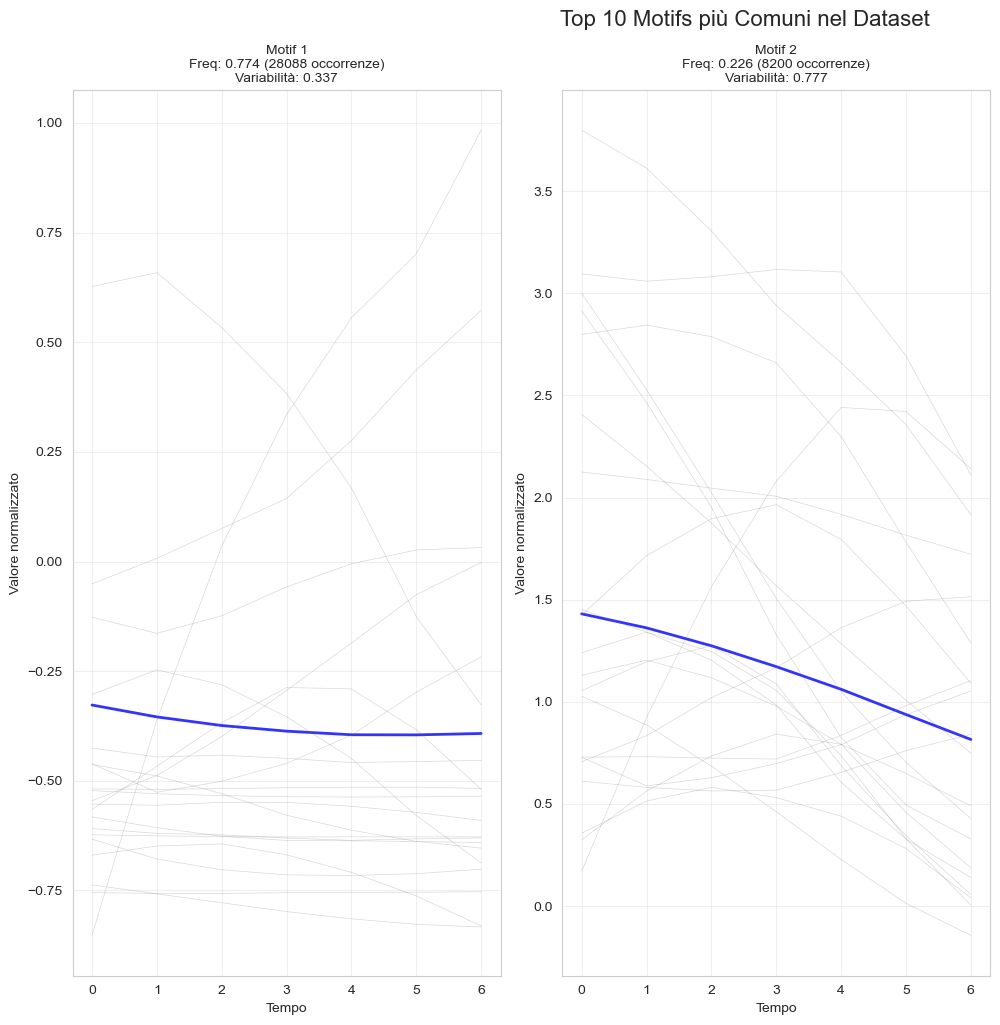


INTERPRETAZIONE MOTIF 1:

📊 STATISTICHE GENERALI:
   • Frequenza: 77.4% (28088 occorrenze su 36288 totali)
   • Variabilità: bassa (σ = 0.337)
   • Trend generale: decrescente

🔍 CARATTERISTICHE DEL PATTERN:
   • Numero di picchi: 0
   • Numero di valli: 1
   • Range valori: -0.395 ÷ -0.327
   • Valore medio: -0.375

🌍 DISTRIBUZIONE NEL DATASET:
   • Presente in 1134 serie diverse su 1134 totali
   • Massimo occorrenze in una singola serie: 30
   • Distribuzione temporale: concentrata

💡 SIGNIFICATO:
   Questo motif rappresenta un pattern molto comune 
   nel dataset, caratterizzato da variabilità significativa.
   È un pattern fondamentale che attraversa molte serie.
        


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform
from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')

class MotifDiscovery:
    def __init__(self, data, window_size=50):
        """
        Inizializza il motif discovery
        
        Args:
            data: numpy array (n_series x n_timestamps) - dataset già normalizzato
            window_size: lunghezza della finestra per i motifs
        """
        self.data = data
        self.window_size = window_size
        self.motifs = []
        self.motif_info = []
        
    def extract_subsequences(self, overlap=0.5):
        """Estrae tutte le sottosequenze possibili dal dataset"""
        step_size = max(1, int(self.window_size * (1 - overlap)))
        subsequences = []
        metadata = []
        
        for series_idx, series in enumerate(self.data):
            for start_idx in range(0, len(series) - self.window_size + 1, step_size):
                subseq = series[start_idx:start_idx + self.window_size]
                subsequences.append(subseq)
                metadata.append({
                    'series_idx': series_idx,
                    'start_idx': start_idx,
                    'end_idx': start_idx + self.window_size
                })
        
        return np.array(subsequences), metadata
    
    def find_optimal_k(self, subsequences, max_k=15):
        """Trova il numero ottimale di cluster usando silhouette score"""
        silhouette_scores = []
        k_range = range(2, min(max_k + 1, len(subsequences) // 10))
        
        for k in k_range:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            cluster_labels = kmeans.fit_predict(subsequences)
            score = silhouette_score(subsequences, cluster_labels)
            silhouette_scores.append(score)
        
        optimal_k = k_range[np.argmax(silhouette_scores)]
        return optimal_k, silhouette_scores, k_range
    
    def discover_motifs(self, n_motifs=10, auto_k=True):
        """Scopre i motifs più comuni"""
        print("Estraendo sottosequenze...")
        subsequences, metadata = self.extract_subsequences()
        print(f"Estratte {len(subsequences)} sottosequenze")
        
        if auto_k and len(subsequences) > 50:
            print("Trovando numero ottimale di cluster...")
            optimal_k, sil_scores, k_range = self.find_optimal_k(subsequences)
            n_motifs = min(n_motifs, optimal_k)
            print(f"Numero ottimale di cluster: {optimal_k}")
        
        # Clustering
        print(f"Eseguendo clustering con {n_motifs} cluster...")
        kmeans = KMeans(n_clusters=n_motifs, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(subsequences)
        
        # Analizza ogni cluster
        for cluster_id in range(n_motifs):
            cluster_mask = cluster_labels == cluster_id
            cluster_subsequences = subsequences[cluster_mask]
            cluster_metadata = [metadata[i] for i in range(len(metadata)) if cluster_mask[i]]
            
            # Statistiche del cluster
            cluster_size = len(cluster_subsequences)
            centroid = kmeans.cluster_centers_[cluster_id]
            
            # Trova la sottosequenza più rappresentativa (più vicina al centroide)
            distances = np.linalg.norm(cluster_subsequences - centroid, axis=1)
            representative_idx = np.argmin(distances)
            representative_subseq = cluster_subsequences[representative_idx]
            representative_meta = cluster_metadata[representative_idx]
            
            # Calcola variabilità intra-cluster
            intra_cluster_std = np.std(cluster_subsequences, axis=0)
            avg_intra_std = np.mean(intra_cluster_std)
            
            # Distribuzione per serie
            series_distribution = {}
            for meta in cluster_metadata:
                series_idx = meta['series_idx']
                series_distribution[series_idx] = series_distribution.get(series_idx, 0) + 1
            
            motif_info = {
                'cluster_id': cluster_id,
                'size': cluster_size,
                'frequency': cluster_size / len(subsequences),
                'centroid': centroid,
                'representative': representative_subseq,
                'representative_meta': representative_meta,
                'intra_cluster_std': avg_intra_std,
                'series_distribution': series_distribution,
                'all_subsequences': cluster_subsequences,
                'all_metadata': cluster_metadata
            }
            
            self.motif_info.append(motif_info)
        
        # Ordina per frequenza
        self.motif_info.sort(key=lambda x: x['frequency'], reverse=True)
        print(f"Motif discovery completato! Trovati {len(self.motif_info)} motifs.")
        
        return self.motif_info
    
    def plot_motifs_overview(self, figsize=(15, 10)):
        """Visualizza tutti i motifs in una griglia"""
        n_motifs = len(self.motif_info)
        cols = 3
        rows = (n_motifs + cols - 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=figsize)
        axes = axes.flatten() if n_motifs > 1 else [axes]
        
        for i, motif in enumerate(self.motif_info):
            ax = axes[i]
            
            # Plot del centroide
            ax.plot(motif['centroid'], 'b-', linewidth=2, label='Centroide', alpha=0.8)
            
            # Plot di alcune istanze del motif (max 20 per leggibilità)
            sample_size = min(20, len(motif['all_subsequences']))
            sample_indices = np.random.choice(len(motif['all_subsequences']), 
                                            sample_size, replace=False)
            
            for idx in sample_indices:
                ax.plot(motif['all_subsequences'][idx], 'gray', alpha=0.3, linewidth=0.5)
            
            ax.set_title(f'Motif {i+1}\nFreq: {motif["frequency"]:.3f} ({motif["size"]} occorrenze)\n'
                        f'Variabilità: {motif["intra_cluster_std"]:.3f}', fontsize=10)
            ax.grid(True, alpha=0.3)
            ax.set_xlabel('Tempo')
            ax.set_ylabel('Valore normalizzato')
        
        # Nasconde assi non utilizzati
        for i in range(n_motifs, len(axes)):
            axes[i].set_visible(False)
        
        plt.tight_layout()
        plt.suptitle('Top 10 Motifs più Comuni nel Dataset', fontsize=16, y=1.02)
        plt.show()
    
    def plot_motif_analysis(self, motif_idx=0, figsize=(15, 8)):
        """Analisi dettagliata di un singolo motif"""
        if motif_idx >= len(self.motif_info):
            print(f"Motif {motif_idx} non trovato!")
            return
        
        motif = self.motif_info[motif_idx]
        
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=figsize)
        
        # 1. Tutte le istanze del motif
        ax1.set_title(f'Motif {motif_idx+1}: Tutte le {motif["size"]} istanze')
        for subseq in motif['all_subsequences']:
            ax1.plot(subseq, 'gray', alpha=0.2, linewidth=0.5)
        ax1.plot(motif['centroid'], 'red', linewidth=3, label='Centroide')
        ax1.plot(motif['representative'], 'blue', linewidth=2, label='Rappresentativo')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax1.set_ylabel('Valore normalizzato')
        
        # 2. Variabilità punto per punto
        ax2.set_title('Variabilità Intra-cluster')
        std_values = np.std(motif['all_subsequences'], axis=0)
        ax2.plot(std_values, 'green', linewidth=2)
        ax2.fill_between(range(len(std_values)), std_values, alpha=0.3, color='green')
        ax2.axhline(y=motif['intra_cluster_std'], color='red', linestyle='--', 
                   label=f'Media: {motif["intra_cluster_std"]:.3f}')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.set_ylabel('Deviazione Standard')
        
        # 3. Distribuzione per serie
        ax3.set_title('Distribuzione per Serie Temporale')
        series_ids = list(motif['series_distribution'].keys())
        counts = list(motif['series_distribution'].values())
        ax3.bar(series_ids, counts)
        ax3.set_xlabel('ID Serie')
        ax3.set_ylabel('Numero di occorrenze')
        ax3.grid(True, alpha=0.3)
        
        # 4. Posizioni temporali
        ax4.set_title('Posizioni Temporali nel Dataset')
        positions = [meta['start_idx'] for meta in motif['all_metadata']]
        series_ids = [meta['series_idx'] for meta in motif['all_metadata']]
        scatter = ax4.scatter(positions, series_ids, alpha=0.6, c=positions, cmap='viridis')
        plt.colorbar(scatter, ax=ax4, label='Posizione temporale')
        ax4.set_xlabel('Posizione nella serie')
        ax4.set_ylabel('ID Serie')
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def get_motif_interpretation(self, motif_idx=0):
        """Genera interpretazione testuale del motif"""
        if motif_idx >= len(self.motif_info):
            return f"Motif {motif_idx} non trovato!"
        
        motif = self.motif_info[motif_idx]
        centroid = motif['centroid']
        
        # Analisi delle caratteristiche del pattern
        trend = "crescente" if centroid[-1] > centroid[0] else "decrescente"
        volatility = "alta" if motif['intra_cluster_std'] > 0.5 else "bassa"
        
        # Picchi e valli
        peaks = []
        valleys = []
        for i in range(1, len(centroid)-1):
            if centroid[i] > centroid[i-1] and centroid[i] > centroid[i+1]:
                peaks.append(i)
            elif centroid[i] < centroid[i-1] and centroid[i] < centroid[i+1]:
                valleys.append(i)
        
        # Distribuzione delle serie
        n_series_affected = len(motif['series_distribution'])
        max_occurrences_series = max(motif['series_distribution'].values())
        
        interpretation = f"""
INTERPRETAZIONE MOTIF {motif_idx + 1}:

📊 STATISTICHE GENERALI:
   • Frequenza: {motif['frequency']:.1%} ({motif['size']} occorrenze su {sum([m['size'] for m in self.motif_info])} totali)
   • Variabilità: {volatility} (σ = {motif['intra_cluster_std']:.3f})
   • Trend generale: {trend}

🔍 CARATTERISTICHE DEL PATTERN:
   • Numero di picchi: {len(peaks)}
   • Numero di valli: {len(valleys)}
   • Range valori: {np.min(centroid):.3f} ÷ {np.max(centroid):.3f}
   • Valore medio: {np.mean(centroid):.3f}

🌍 DISTRIBUZIONE NEL DATASET:
   • Presente in {n_series_affected} serie diverse su {len(self.data)} totali
   • Massimo occorrenze in una singola serie: {max_occurrences_series}
   • Distribuzione temporale: {'uniforme' if len(set([m['start_idx'] // 100 for m in motif['all_metadata']])) > 3 else 'concentrata'}

💡 SIGNIFICATO:
   Questo motif rappresenta un pattern {'molto comune' if motif['frequency'] > 0.1 else 'moderatamente comune'} 
   nel dataset, caratterizzato da {'alta ripetibilità' if motif['intra_cluster_std'] < 0.3 else 'variabilità significativa'}.
   {'È un pattern fondamentale che attraversa molte serie.' if n_series_affected > len(self.data) * 0.3 else 'Appare selettivamente in alcune serie specifiche.'}
        """
        
        return interpretation
    
    def export_motifs_summary(self):
        """Esporta riassunto dei motifs"""
        summary = []
        for i, motif in enumerate(self.motif_info):
            summary.append({
                'motif_id': i + 1,
                'frequency': motif['frequency'],
                'size': motif['size'],
                'variability': motif['intra_cluster_std'],
                'n_series': len(motif['series_distribution']),
                'trend': 'crescente' if motif['centroid'][-1] > motif['centroid'][0] else 'decrescente',
                'max_value': np.max(motif['centroid']),
                'min_value': np.min(motif['centroid']),
                'mean_value': np.mean(motif['centroid'])
            })
        
        return pd.DataFrame(summary)

# Per utilizzare con i tuoi dati:
md = MotifDiscovery(df_timeseries.values, window_size=7)
motifs = md.discover_motifs(n_motifs=5)
md.plot_motifs_overview()
print(md.get_motif_interpretation(0))